skipped 0% of entries


array([[<Axes: title={'center': 'minutes_late'}>]], dtype=object)

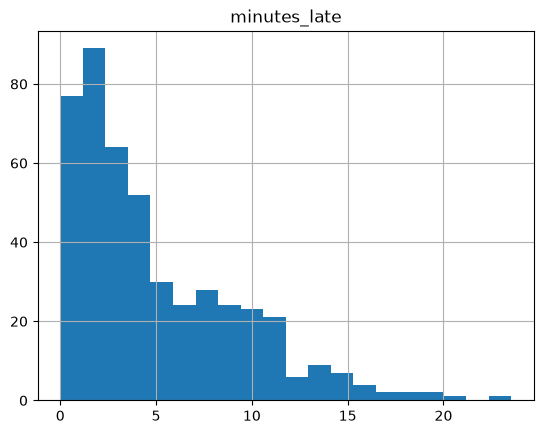

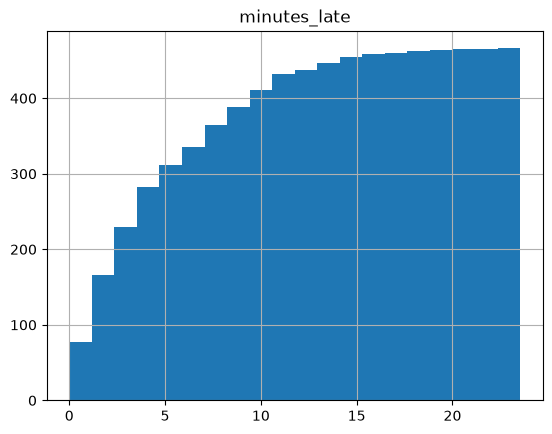

In [2]:
from pandas import DataFrame
import sqlite3
from datetime import datetime

con = sqlite3.connect("bus.db")

deltas = []

cur = con.cursor()
res = cur.execute("SELECT expected, actual FROM departures").fetchall()

total_skipped = 0

for row in res:
    
    expected = datetime.fromtimestamp(row[0])

    actual = datetime.fromtimestamp(row[1])

    if expected > datetime.now():
        total_skipped += 1
        continue
    # if excpected < actual -> bus came late
    delta =  (actual - expected).seconds  if expected < actual else (expected - actual).seconds * -1
    deltas.append(delta / 60) # conver to minutes


points = {"minutes_late" : list(filter(lambda s : abs(s) < 1000,deltas))}
print(f"skipped {int((total_skipped / len(res)) * 100)}% of entries")
df = DataFrame(data=points)
bins = 20
df.hist(bins=bins) # regular pmf
df.hist(bins=bins, cumulative=True) # cdf



In [10]:
print(df.mean())
print(df.median())

minutes_late    2.914259
dtype: float64
minutes_late    2.316667
dtype: float64
